In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
# FEATURES_TO_CONSIDER = [0, 1, 15, 16]
FEATURES_TO_CONSIDER = torch.arange(29)

KEEP_ONLY_COORDS = True

In [3]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.55803349734801, 24.44237252008143)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.42it/s]


In [5]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001].reshape(-1, 1001)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [6]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])


def normalize_dataset_coords(dataset_, features_to_consider_only=False):
    return dataset_
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = (dataset - dataset_mean) / dataset_std
    else:
        dataset = (dataset - dataset_mean[FEATURES_TO_CONSIDER]) / dataset_std[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

def denormalize_dataset_coords(dataset_, features_to_consider_only=False):
    return dataset_
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = dataset * dataset_std + dataset_mean
    else:
        dataset = dataset * dataset_std[FEATURES_TO_CONSIDER] + dataset_mean[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [7]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [8]:
class FRENetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=2, num_layers=2, d_model=128):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.d_model = d_model
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.d_model, 
                num_heads, 
                dim_feedforward=4*self.d_model, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.d_model, self.d_model)
        self.encoder_log_std = nn.Linear(self.d_model, self.d_model)

        self.state_embed = nn.Linear(self.state_dim, self.d_model // 2)
        self.action_embed = nn.Linear(self.action_dim, self.d_model // 2)

        self.action_predict = nn.Sequential(
            nn.Linear(self.state_dim + self.d_model, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, action_dim),
            nn.Tanh()
        )
        
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1, max_len=200)



    def get_transformer_encoding(self, states, actions, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
        action_emb = self.action_embed(actions)
        
        state_action_emb = torch.concat([state_emb, action_emb], dim=-1)
        
        x = self.positional_encoding(state_action_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_action_pred(self, w, states): # Reward Pairs: [batch, seq, obs_dim]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, states], axis=-1)
        
        reward_pred = self.action_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

# FRE:

In [9]:
class MLPRewards:
    def __init__(self, N, obs_len):

        self.N = N
        
        self.param_w1 = torch.normal(0, 1, size=(self.N, obs_len, 32), device=device) * np.sqrt(1/32)
        self.param_b1 = torch.normal(0, 1, size=(self.N, 1, 32), device=device) * np.sqrt(16)
        self.param_w2 = torch.normal(0, 1, size=(self.N, 32, 1), device=device) * np.sqrt(1/16)
    
    def sample(self, N):
        return torch.randint(0, self.N, (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        # device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, self.N, size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded]
        param1_b = self.param_b1[param_id_expanded]
        param2_w = self.param_w2[param_id_expanded]

        # obs[..., 2:] = 0.0
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        x = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        x = x + param1_b
        x = torch.tanh(x)
        r = torch.matmul(x, param2_w) # [batch, (pairs), 1, 1]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id
    
# mlp_rewards = MLPRewards(N=10000, obs_len=29)

In [10]:
class LinearRewards:
    def __init__(self, N, obs_len):

        self.N = N
        
        self.param_w1 = torch.rand(size=(self.N, obs_len, 1)) * 2 - 1
        self.random_mask = torch.rand(size=(self.N, obs_len)) < 0.9
        self.random_mask[..., :2] = True
        
        random_mask_positive = np.random.randint(2, obs_len, size=(N,))
        self.random_mask[np.arange(N), random_mask_positive] = False # Force at least one positive weight.
        
        self.param_w1 = self.param_w1.to(device)
        self.random_mask = self.random_mask.to(device)
        

    def sample(self, N):
        return torch.randint(0, self.N, (N,))

    def __call__(self, obs, param_id=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param_id.shape = (batch_size, 1)
        """
        
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, _ = param_id.shape
        assert (batch_size == batch_size_)
        
        # device = obs.device
        
        if param_id is None:
            param_id = torch.randint(0, self.N, size=(obs.shape[0], 1))
        
        param_id_expanded = param_id.repeat(1, obs.shape[1]).cpu()
        param1_w = self.param_w1[param_id_expanded]
        mask = self.random_mask[param_id_expanded]
        obs = (~mask) * obs
        
        x = torch.unsqueeze(obs, -2) # [batch, (pairs), 1, features_in]
        r = torch.matmul(x, param1_w) # [batch, (pairs), 1, features_out]
        r = r.squeeze(-1).squeeze(-1) # [batch, (pairs)]
        r = torch.clip(r, -1, 1)

        return r, param_id

In [11]:
class GoalRewards:
    def __init__(self):
        pass
    
    def sample_goals(self, N):
        goals = dataset_trajectories[
            torch.randint(0, num_trajectories, (N,)),
            torch.randint(0, len_trajectory, (N,)),
        ]
        # goals = dataset_trajectories[torch.tensor([0]).repeat(N), torch.tensor([0]).repeat(N),]
        return goals
    
    # def get_states(self, num_states, goals):
    #     cond = (dataset_trajectories[..., :2] - goal[..., :2]).norm(dim=-1) < 0.5
    #     dataset_trajectories_cuda[cond][torch.randint(0, cond.sum(), (1,))]
    
    def __call__(self, obs, goals=None):
        """
        obs.shape = (batch_size, num_samples, obs_dim)
        param.shape = (batch_size, obs_dim)
        """
        batch_size, num_samples, obs_dim = obs.shape
        batch_size_, obs_dim_ = goals.shape
        assert (batch_size == batch_size_) and (obs_dim == obs_dim_)
        
        device = obs.device
        
        goals = goals.to(device)

        # r = torch.norm(obs - goals.unsqueeze(-2), dim=-1) < 2
        r = torch.norm(obs[..., :2] - goals[..., :2].unsqueeze(-2), dim=-1) < 2
        r = r.float() * 2 - 1
        r = torch.clip(r, -1, 1)

        return r, goals


In [12]:
linear_rewards = LinearRewards(N=10000, obs_len=29)
mlp_rewards = MLPRewards(N=10000, obs_len=29)
goal_rewards = GoalRewards()

In [13]:
def sample_reward_function_fre(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, len(FEATURES_TO_CONSIDER)).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))

    for b in range(batch_size):
        reward_type = torch.randint(0, 3, (1,)) # 0: goal_reaching | 1: linear_reward | 2: mlp_reward
        
        reward_type = 0
        
        reward_params[b, 0] = reward_type
        if reward_type == 0:
            goal = goal_rewards.sample_goals(1)
            goal = goal.repeat(1, 1)
            r, param_id = goal_rewards(random_states[[b]], goals=goal)    
            reward_params[b, 1:1+obs_dim] = param_id
            random_states[b, 0] = goal
            r[0, 0] = 1.
            
        elif reward_type == 1:
            param_id = linear_rewards.sample(1).unsqueeze(0)
            r, param_id = linear_rewards(random_states[[b]], param_id)
            reward_params[b, 1] = param_id
            
        elif reward_type == 2:
            param_id = mlp_rewards.sample(1).unsqueeze(0)
            r, param_id = mlp_rewards(random_states[[b]], param_id) 
            reward_params[b, 1] = param_id
            
        random_states_rewards[b] = r
        
    return reward_params, random_states, random_states_rewards

In [14]:
# def get_reward_(reward_params, random_states):

#     assert len(reward_params.shape) == 2
#     assert len(random_states.shape) == 3
#     assert reward_params.shape[0] == random_states.shape[0]
    
#     all_rewards = torch.zeros((random_states.shape[0], random_states.shape[1]), device=device)

#     for b in range(reward_params.shape[0]):
#         param = reward_params[b]
#         x = random_states[b].unsqueeze(0)
#         if (param[0] == 2):
#             rewards, _ = mlp_rewards(obs=x, param_id=param[1].reshape(1, 1).repeat(x.shape[0], 1).long())
#         elif (param[0] == 1):
#             rewards, _ = linear_rewards(obs=x, param_id=param[1].reshape(1, 1).repeat(x.shape[0], 1).long())
#         elif (param[0] == 0):
#             rewards, _ = goal_rewards(obs=x, goals=param[1:obs_dim+1].unsqueeze(0).repeat(x.shape[0], 1))
        
#         all_rewards[b] = rewards.float()

#     return all_rewards

In [15]:
def get_reward(reward_params, random_states, same_obs=False):

    if not same_obs:
        assert len(reward_params.shape) == 2
        assert len(random_states.shape) == 3
        assert reward_params.shape[0] == random_states.shape[0]
    else:
        assert len(reward_params.shape) == 2
        assert len(random_states.shape) == 2

    all_rewards = torch.zeros((random_states.shape[0], random_states.shape[1]), device=device)

    for reward_type in [0, 1, 2]:

        idx = torch.nonzero(reward_params[:, 0] == reward_type).flatten()

        if len(idx) == 0:
            continue
        
        if not same_obs:
            x = random_states[idx]
        else:
            x = random_states
        params = reward_params[idx]

        
        if reward_type == 0:
            rewards, _ = goal_rewards(
                obs=x, 
                goals=params[:, 1:obs_dim+1]
            )
        elif reward_type == 1:
            rewards, _ = linear_rewards(
                obs=x, 
                param_id=params[:, [1]].long()
            )
        elif reward_type == 2:
            rewards, _ = mlp_rewards(
                obs=x, 
                param_id=params[:, [1]].long()
            )

        all_rewards[idx] = rewards
        
    return all_rewards

In [16]:
# reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=16, num_random_samples=200)

# get_reward(reward_params, random_states)

In [17]:
# reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=16, num_random_samples=200)

# for b in range(16):
#     # plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1])
#     plt.scatter(random_states[b, :, 0].cpu(), random_states[b, :, 1].cpu(), c=random_states_rewards[b], vmin=-1, vmax=1)
#     plt.show()

# FRE:

In [18]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)
        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )


    def get_transformer_encoding(self, reward_state_pairs):
        reward_states = reward_state_pairs[:, :, :-1]
        reward_values = reward_state_pairs[:, :, -1]
        reward_values_idx = torch.floor((reward_values / 2.0 + 0.5) * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        reward_state_emb = self.state_embed(reward_states)
        reward_state_val = self.reward_embed(reward_values_idx)
        
        reward_state_pairs = torch.concatenate([reward_state_emb, reward_state_val], axis=-1)

        w_pre = self.encoder_transformer(reward_state_pairs) # [batch, reward_pairs, emb_dim]
        
        w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [19]:
fre_network = FRENetwork(obs_len=obs_dim).to(device)
fre_network.load_state_dict(torch.load('shared_models/offline_fre-fre_network.pth'))
optimimizer = torch.optim.Adam(fre_network.parameters(), lr=0.001)

reward_losses = []
kl_losses = []

/tmp/ipykernel_253596/661315295.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fre_network.load_state_dict(torch.load('shared_models/offline_fre-fre_network.pth'))


In [20]:
# num_encode_states = 128
# num_decode_states = 128

# for i in tqdm(range(10_000)):
    
#     reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=256, num_random_samples=(num_encode_states+num_decode_states))
    
#     encode_obs = random_states[:, :num_encode_states, :].to(device)
#     decode_obs = random_states[:, num_encode_states:, :].to(device)
    
#     encode_rewards = random_states_rewards[:, :num_encode_states, None].to(device)
#     decode_rewards = random_states_rewards[:, num_encode_states:, None].to(device)

            
#     # encode_rewards, goals = goal_rewards(encode_obs, goals=None)
#     # decode_rewards, goals = goal_rewards(decode_obs, goals=goals)
    
#     reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
#     w_mean, w_log_std = fre_network.get_transformer_encoding(reward_state_pairs)
    
    
#     # Calculate the loss:
    
#     w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
#     # w = w_mean
#     rewards_pred = fre_network.get_reward_pred(w, decode_obs)
    
#     reward_pred_loss = ((rewards_pred - decode_rewards)**2).mean()
#     kl_loss = -0.5 * (1 + w_log_std - w_mean**2 - torch.exp(w_log_std)).mean()
#     loss = reward_pred_loss + kl_loss * 0.01
    
#     optimimizer.zero_grad()
#     loss.backward()
#     optimimizer.step()
    
#     reward_losses.append(reward_pred_loss.item())
#     kl_losses.append(kl_loss.item())
    
#     if i % 20 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
#         axs[0].plot(reward_losses)
#         # axs[0].set_xscale('log')
#         axs[0].set_ylim(0, 0.5)
#         axs[1].plot(kl_losses)
#         plt.show()
        


In [21]:
# torch.save(fre_network.state_dict(), 'models/offline_fre-fre_network.pth')

In [22]:
from utils.antmaze_benchmark import VelocityRewardFunction, SimplexRewardFunction, TestRewPath, TestRewLoop, TestRewMatrixEdges, goal_reaching_reward

velocity_reward_function = VelocityRewardFunction()
simplex_reward_function = SimplexRewardFunction(num_simplex=10)

benchmarks = [
    (goal_reaching_reward, 'goal_bottom', np.array([28, 0])),
    (goal_reaching_reward, 'goal_left', np.array([0, 15])),
    (goal_reaching_reward, 'goal_top', np.array([35, 24])),
    (goal_reaching_reward, 'goal_center', np.array([12, 24])), 
    (goal_reaching_reward, 'goal_right', np.array([33, 16])),
    (velocity_reward_function.compute_reward, 'vel_left', [-1, 0]),
    (velocity_reward_function.compute_reward, 'vel_up', [0, 1]),
    (velocity_reward_function.compute_reward, 'vel_down', [0, -1]),
    (velocity_reward_function.compute_reward, 'vel_right', [1, 0]),
    (simplex_reward_function.compute_reward, 'simplex_1', 1),
    (simplex_reward_function.compute_reward, 'simplex_2', 2),
    (simplex_reward_function.compute_reward, 'simplex_3', 3),
    (simplex_reward_function.compute_reward, 'simplex_4', 4),
    (simplex_reward_function.compute_reward, 'simplex_5', 5),
    (TestRewPath().compute_reward, 'path_center', None),
    (TestRewLoop().compute_reward, 'path_loop', None),
    (TestRewMatrixEdges().compute_reward, 'path_edges', None)
]

Generating simplex seeds


100%|██████████| 10/10 [00:00<00:00, 19.89it/s]


In [23]:
num_eval_states = 10_000

reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=(128+num_eval_states))

encode_obs = random_states[:, :128, :].to(device)
decode_obs = random_states[:, 128:, :].to(device)

encode_rewards = random_states_rewards[:, :128, None].to(device)
decode_rewards = random_states_rewards[:, 128:, None].to(device)

# benchmark_id = 1
# encode_rewards = benchmarks[benchmark_id][0](encode_obs.cpu(), np.array([0, 15])).unsqueeze(-1).to(device)
# decode_rewards = benchmarks[benchmark_id][0](decode_obs.cpu(), np.array([0, 15])).unsqueeze(-1).to(device)

        
# encode_rewards, goals = goal_rewards(encode_obs, goals=None)
# decode_rewards, goals = goal_rewards(decode_obs, goals=goals)

reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)

with torch.no_grad():
    w_mean, w_log_std = fre_network.get_transformer_encoding(reward_state_pairs)

    # Calculate the loss:

    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    
    rewards_pred = fre_network.get_reward_pred(w, decode_obs)

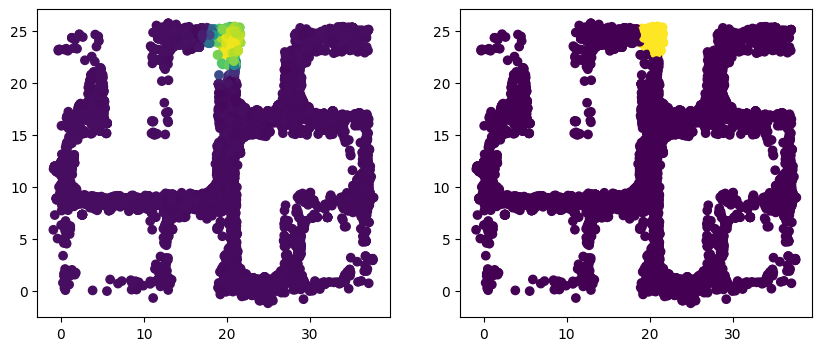

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(decode_obs[..., 0].cpu(), decode_obs[..., 1].cpu(), c=rewards_pred.cpu())
axs[1].scatter(decode_obs[..., 0].cpu(), decode_obs[..., 1].cpu(), c=decode_rewards.cpu())

# IQL:

In [25]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """Generic MLP with Mish activation and LayerNorm."""
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # Add hidden layers with Mish activation and LayerNorm
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Mish())
            # layers.append(nn.LayerNorm(hidden_dim))
            prev_dim = hidden_dim  # Update input size for next layer
        
        # Final output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class ValueCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dims):
        super().__init__()
        self.model = MLP(obs_dim, hidden_dims, output_dim=1)

    def forward(self, x):
        return self.model(x)


class Critic(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims):
        super().__init__()

        self.model1 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)
        self.model2 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)

    def forward(self, x, action):
        x = torch.cat((x, action), dim=-1)
        
        q1 = self.model1(x)
        q2 = self.model2(x)
        
        return q1, q2



class Actor(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dims, init_std=0.0):
        super().__init__()
        self.model = MLP(input_dim, hidden_dims, output_dim=action_dim)  # MLP only predicts mean
        
        # Learnable log standard deviation (initialized to `init_std`)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_std)

    def forward(self, x, temperature=1.0):
        mean = self.model(x)  # Predict action mean

        log_std = torch.clip(self.log_std, -20, 2)
        mean = torch.clip(mean, -5, 5)

        return torch.distributions.Normal(
            mean, 
            torch.exp(log_std)*temperature
        )


from torch.optim.lr_scheduler import CosineAnnealingLR
import copy


class IQL(nn.Module):
    def __init__(self, state_dim, action_dim, w_dim=128):
        super(IQL, self).__init__()
        self.obs_len = state_dim
                
        self.critic = Critic(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        self.target_critic = copy.deepcopy(self.critic)
        for param in self.target_critic.parameters():
            param.requires_grad = False
        
        self.value = ValueCritic(w_dim + state_dim, hidden_dims=[256, 256])        
        self.actor = Actor(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=0.003)
        self.value_optim = torch.optim.Adam(self.value.parameters(), lr=0.003)
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=0.003)
        self.actor_lr_schedule = CosineAnnealingLR(self.actor_optim, 100000)
        
        
    def get_value(self, w, obs):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.value(w_and_obs)

    def get_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.critic(w_and_obs, actions)
    
    def get_target_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.target_critic(w_and_obs, actions)

    def get_actor(self, w, obs, temperature=1.0):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.actor(w_and_obs, temperature)
    
    
    
# def update_target_critic(critic, target_critic, tau):

#     critic_state_dict = critic.state_dict()
#     target_critic_state_dict = target_critic.state_dict()

#     for key in critic_state_dict:
#         target_critic_state_dict[key] = tau * critic_state_dict[key] + (1 - tau) * target_critic_state_dict[key]

#     target_critic.load_state_dict(target_critic_state_dict)
    
    
def update_target_critic(source, target, alpha):
    for target_param, source_param in zip(target.parameters(), source.parameters()):
        target_param.data.mul_(1. - alpha).add_(source_param.data, alpha=alpha)
    
    
def expectile_loss(u, expectile=0.7):
    weight = torch.where(
        u.detach() >= 0, 
        torch.tensor(expectile, dtype=u.dtype), 
        torch.tensor(1 - expectile, dtype=u.dtype)
    )
    return weight * (u ** 2)


def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]

In [26]:
def get_iql_training_data(batch_size, num_states):

    trajectory_idx = torch.randint(0, num_trajectories, (batch_size*num_states,))
    state_idx = torch.randint(0, len_trajectory, (batch_size*num_states,)) % 1000

    states = dataset_trajectories[trajectory_idx, state_idx].reshape(batch_size, num_states, obs_dim)
    next_states = dataset_trajectories[trajectory_idx, state_idx+1].reshape(batch_size, num_states, obs_dim)
    actions = dataset_actions[trajectory_idx, state_idx].reshape(batch_size, num_states, 8)
    masks = ~dataset_timeouts[trajectory_idx, state_idx+1].reshape(batch_size, num_states, 1)
    
    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'next_states': next_states.to(device),
        'masks': masks.to(device),
        'trajectory_idx': trajectory_idx.reshape(batch_size, num_states),
        'state_idx': state_idx.reshape(batch_size, num_states)
    }

In [27]:
def get_iql_training_data_with_G(batch_size, num_states, reward_params, ratio, top_k):
    assert batch_size == reward_params.shape[0]
    num_considered_states = 100
    gamma = 0.99


    states = torch.zeros((batch_size, num_states, obs_dim), device=device)
    next_states = torch.zeros((batch_size, num_states, obs_dim), device=device)
    actions = torch.zeros((batch_size, num_states, 8), device=device)
    masks = torch.zeros((batch_size, num_states, 1), device=device)
    G_s = torch.zeros((batch_size, num_states, 1), device=device)
    G_next_s = torch.zeros((batch_size, num_states, 1), device=device)

    # Find the top_k trajectory, and 
    
    top_k_num_states = int(num_states * ratio)
    num_radom_states = num_states - top_k_num_states
    
    if ratio != 0:
        
        state_idx = torch.linspace(0, len_trajectory-1, num_considered_states).long()
        x = dataset_trajectories_cuda[:, state_idx]

        for b in range(batch_size):
            # Find the top trajectories:
            param = reward_params[b]

            # print(x.shape, param.shape)
            
            if (param[0] == 2):
                rewards, _ = mlp_rewards(obs=x, param_id=param[1].reshape(1, 1).repeat(x.shape[0], 1).long())
            elif (param[0] == 1):
                rewards, _ = linear_rewards(obs=x, param_id=param[1].reshape(1, 1).repeat(x.shape[0], 1).long())
            elif (param[0] == 0):
                rewards, _ = goal_rewards(obs=x, goals=param[1:obs_dim+1].unsqueeze(0).repeat(x.shape[0], 1))
            
            cum_rewards = rewards.sum(dim=1)

            sorted_trajectories_idx = cum_rewards.argsort(descending=True)
            # sorted_cum_rewards = cum_rewards[sorted_trajectories_idx]

            # top_k = 50
            top_k_trajectories_idx = sorted_trajectories_idx[:top_k].cpu()


            # Calculate the discounted cumulative reward G(s) for each state from the top trajectories

            top_k_trajectories = dataset_trajectories_cuda[top_k_trajectories_idx]

            rewards = get_reward(
                reward_params=param.unsqueeze(0).repeat(top_k, 1),
                random_states=top_k_trajectories
            )
                
            discounts = gamma ** torch.arange(len_trajectory, device=rewards.device).unsqueeze(0)
            discounted_rewards = rewards * discounts
            reversed_cumsum = torch.flip(torch.cumsum(torch.flip(discounted_rewards, dims=[1]), dim=1), dims=[1])
            discounted_sum_per_step = reversed_cumsum / discounts


            # Select 50% of the states from the top trajectories:

            top_k_t_idx = torch.randint(0, top_k, (top_k_num_states,))
            top_k_s_idx = torch.randint(0, len_trajectory-1, (top_k_num_states,))

            states[b, :top_k_num_states] = top_k_trajectories[top_k_t_idx, top_k_s_idx]
            next_states[b, :top_k_num_states] = top_k_trajectories[top_k_t_idx, top_k_s_idx+1]
            actions[b, :top_k_num_states] = dataset_actions[top_k_trajectories_idx][top_k_t_idx, top_k_s_idx]
            masks[b, :top_k_num_states] = ~dataset_timeouts[top_k_trajectories_idx][top_k_t_idx, top_k_s_idx+1].unsqueeze(-1)
            G_s[b, :top_k_num_states] = discounted_sum_per_step[top_k_t_idx, top_k_s_idx].unsqueeze(-1)
            G_next_s[b, :top_k_num_states] = discounted_sum_per_step[top_k_t_idx, top_k_s_idx+1].unsqueeze(-1)


        # Select the remaining 50% states randomly:


    trajectory_idx = torch.randint(0, num_trajectories, (batch_size*num_radom_states,))
    state_idx = torch.randint(0, len_trajectory, (batch_size*num_radom_states,)) % 1000

    states[:, top_k_num_states:] = dataset_trajectories[trajectory_idx, state_idx].reshape(batch_size, num_radom_states, obs_dim)
    next_states[:, top_k_num_states:] = dataset_trajectories[trajectory_idx, state_idx+1].reshape(batch_size, num_radom_states, obs_dim)
    actions[:, top_k_num_states:] = dataset_actions[trajectory_idx, state_idx].reshape(batch_size, num_radom_states, 8)
    masks[:, top_k_num_states:] = ~dataset_timeouts[trajectory_idx, state_idx+1].reshape(batch_size, num_radom_states, 1)

    alpha = (G_s != 0).float()
    
    # print(states.shape, reward_params.shape)
    rewards = get_reward(reward_params=reward_params, random_states=states).unsqueeze(-1)
    
    
    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'rewards': rewards.to(device),
        'next_states': next_states.to(device),
        'masks': masks.to(device),
        'G_s': G_s.to(device),
        'G_next_s': G_next_s.to(device),
        'alpha': alpha      
    } 


In [29]:
iql_agent = IQL(state_dim=obs_dim, action_dim=8).to(device)
iql_agent.load_state_dict(torch.load('shared_models/iql_agent.pth'))

actor_losses = []
v_losses, q_losses = [], []
mse_errors = []
stds = []

/tmp/ipykernel_253596/3040112749.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  iql_agent.load_state_dict(torch.load('shared_models/iql_agent.pth'))


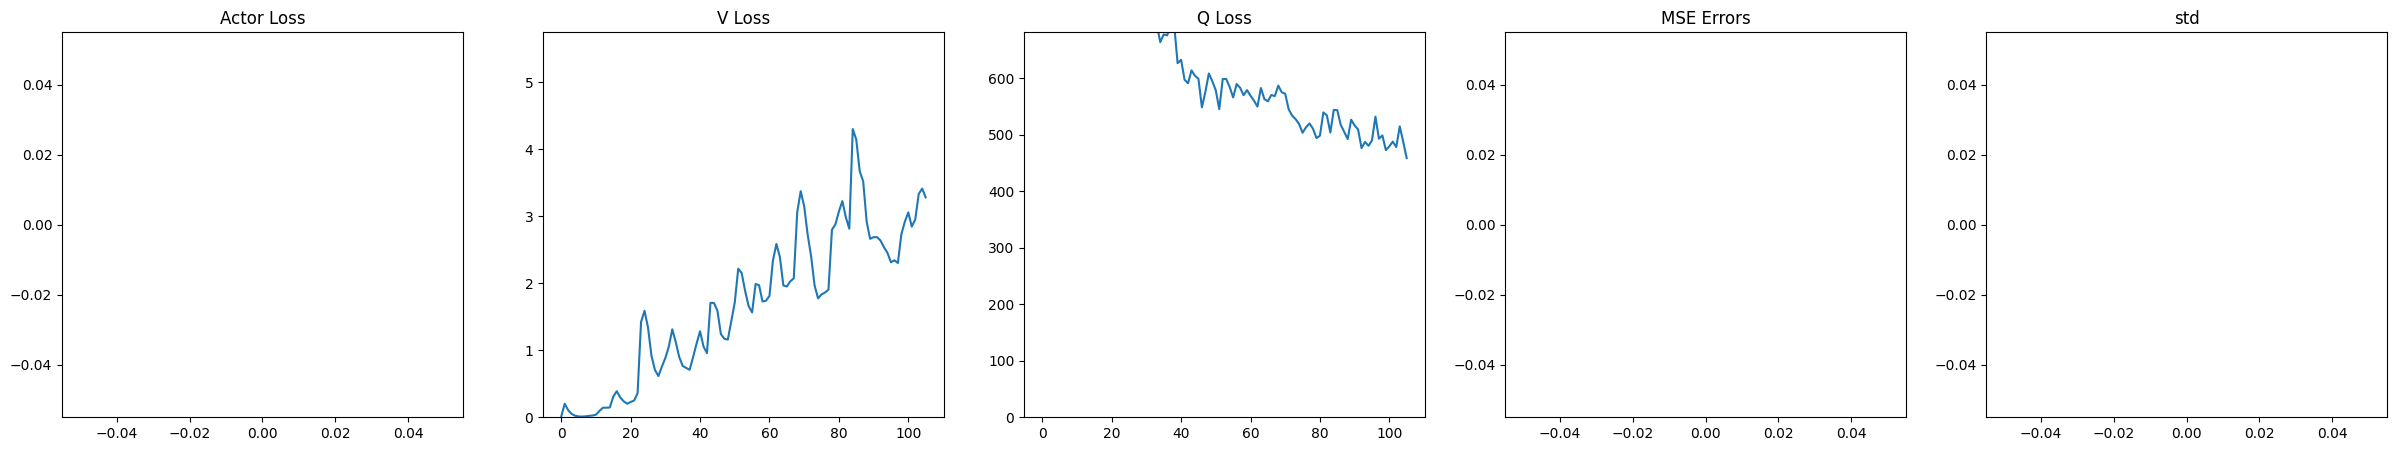

 96%|█████████▌| 962/1000 [09:14<00:21,  1.74it/s]


KeyboardInterrupt: 

In [ ]:
config = {
    'expectile': 0.8,
    'temperature': 3.0,
    'discount': 0.99,
    'tau': 0.005,
}

iql_batch_size = 64
iql_num_states = 512



for timestep in tqdm(range(1000)):

    
    reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=iql_batch_size, num_random_samples=128)
    encode_obs = random_states[:, :128, :].to(device)
    encode_rewards = random_states_rewards[:, :128, None].to(device)
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    
    batch = get_iql_training_data_with_G(
        batch_size=iql_batch_size, 
        num_states=iql_num_states,
        reward_params=reward_params,
        ratio=0.5,
        top_k=10
    )
    
    # break
    
    
    with torch.no_grad():
        w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)

    # break

    # Implicit Q-Learning
    w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
    
    with torch.no_grad():
        
        target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
        target_q1, target_q2 = target_q1.detach(), target_q2.detach()
        target_q = torch.minimum(target_q1, target_q2)
        next_v = iql_agent.get_value(w_target, batch['next_states']).detach()
        next_v = batch['alpha'] * batch['G_next_s'] + (1 - batch['alpha']) * next_v
    
    
    # Value Loss: Update V towards expectile of min(q1, q2).
    
    v = iql_agent.get_value(w_target, batch['states'])
    # v_loss_G = expectile_loss(batch['G_s'] - v, config['expectile'])
    v_loss_Q = expectile_loss(target_q - v, config['expectile'])
    
    # v_loss = batch['alpha'] * v_loss_G + (1 - batch['alpha']) * v_loss_Q
    v_loss = v_loss_Q
    
    # break
    
    v_loss = v_loss.mean()

    iql_agent.value.zero_grad(set_to_none=True)
    v_loss.backward()
    iql_agent.value_optim.step()

    # Critic Loss. Update Q = r #############################
    
    targets = batch['rewards'] + config['discount'] * batch['masks'] * next_v
    

    q1, q2 = iql_agent.get_critic(w_target, batch['states'], batch['actions'])
    q_loss = ((q1 - targets).pow(2).mean() + (q2 - targets).pow(2).mean()) / 2
    q_loss = q_loss
    
    iql_agent.critic.zero_grad(set_to_none=True)
    q_loss.backward()
    iql_agent.critic_optim.step()


    update_target_critic(iql_agent.critic, iql_agent.target_critic, config['tau'])


    value_info = {
        'v_loss': v_loss,
        'q_loss': q_loss,
        'v': v.mean(),
        'q': torch.minimum(q1, q2).mean(),
    }


    ########################################################################################
    
    
    
    v_losses.append(v_loss.item())
    q_losses.append(q_loss.item())
    
    if timestep % 50 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 5, figsize=(30, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        # axs[0].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(mse_errors))
        # axs[3].set_ylim(0,max(mse_errors[-100:]))
        axs[3].set_title("MSE Errors")
        
        axs[4].plot(smooth_and_downsample(stds))
        axs[4].set_title("std")

        plt.show()
        
    # break

In [ ]:
iql_agent.actor = Actor(128 + 29, 8, hidden_dims=[256, 256]).to(device)        
iql_agent.actor_optim = torch.optim.Adam(iql_agent.actor.parameters(), lr=0.003)
iql_agent.actor_lr_schedule = CosineAnnealingLR(iql_agent.actor_optim, 5000)

actor_losses = []
mse_errors = []
stds = []

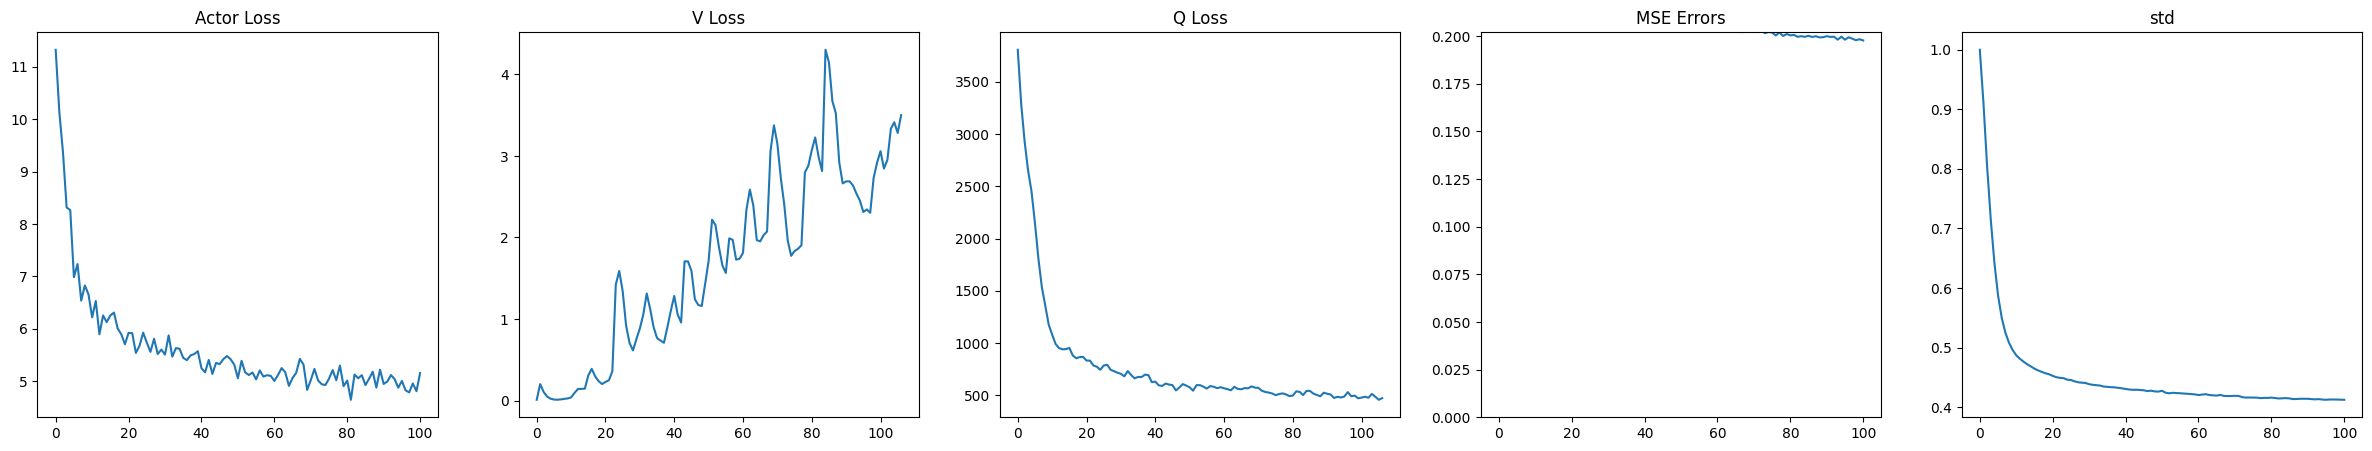

 83%|████████▎ | 4132/5000 [04:50<01:01, 14.23it/s]


KeyboardInterrupt: 

In [ ]:
for timestep in tqdm(range(5000)):

    
    reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=iql_batch_size, num_random_samples=128)
    encode_obs = random_states[:, :128, :].to(device)
    encode_rewards = random_states_rewards[:, :128, None].to(device)
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    
    batch = get_iql_training_data_with_G(
        batch_size=iql_batch_size, 
        num_states=iql_num_states,
        reward_params=reward_params,
        ratio=0.0,
        top_k=-1
    )
    
    # break
    
    
    with torch.no_grad():
        w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)

    # break

    # Implicit Q-Learning
    w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
    
    with torch.no_grad():
        
        target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
        target_q1, target_q2 = target_q1.detach(), target_q2.detach()
        target_q = torch.minimum(target_q1, target_q2)
        v = iql_agent.get_value(w_target, batch['states'])
    

    # Actor Loss ############################################

    adv = (target_q - v).detach()
    actions = batch['actions']
    exp_a = torch.exp(adv.detach() * 3).clamp(max=100)
    
    dist = iql_agent.get_actor(w_target, batch['states'])
    log_probs = dist.log_prob(actions)
    actor_loss = -(exp_a * log_probs).mean()
    
    iql_agent.actor.zero_grad(set_to_none=True)
    actor_loss.backward()
    iql_agent.actor_optim.step()
    iql_agent.actor_lr_schedule.step()
    
    
    std = dist.stddev.mean()
    mse_error = ((dist.loc - batch['actions'])**2).mean()
    
    actor_info = {
        'actor_loss': actor_loss,
        'std': std,
        'adv': adv.mean(),
        'mse_error': mse_error,
    }

    ########################################################################################
    
    
    actor_losses.append(actor_loss.item())
    mse_errors.append(mse_error.item())
    stds.append(std.item())
    
    if timestep % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 5, figsize=(30, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        # axs[0].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        # axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        # axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(mse_errors))
        axs[3].set_ylim(0,max(mse_errors[-100:]))
        axs[3].set_title("MSE Errors")
        
        axs[4].plot(smooth_and_downsample(stds))
        axs[4].set_title("std")

        plt.show()
        
    # break

In [ ]:
# plt.hist(exp_a.cpu().flatten())

In [42]:
reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=128)
encode_obs = random_states[:, :128, :].to(device)
encode_rewards = random_states_rewards[:, :128, None].to(device)
reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
batch = get_iql_training_data_with_G(
    batch_size=1, 
    num_states=2000,
    reward_params=reward_params,
    ratio=0.0,
    top_k=50
)

with torch.no_grad():
    w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)

# break

# Implicit Q-Learning
w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)

with torch.no_grad():
    
    target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
    target_q1, target_q2 = target_q1.detach(), target_q2.detach()
    target_q = torch.minimum(target_q1, target_q2)
    v = iql_agent.get_value(w_target, batch['states'])

exp_a = torch.exp(target_q - v).clamp(max=2)
# exp_a = target_q - v

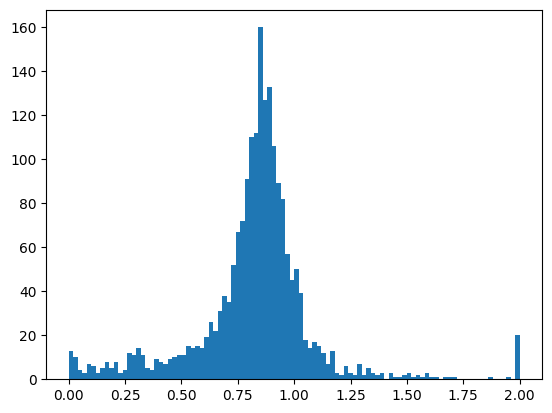

In [43]:
_ = plt.hist(exp_a.cpu().flatten(), bins=100)

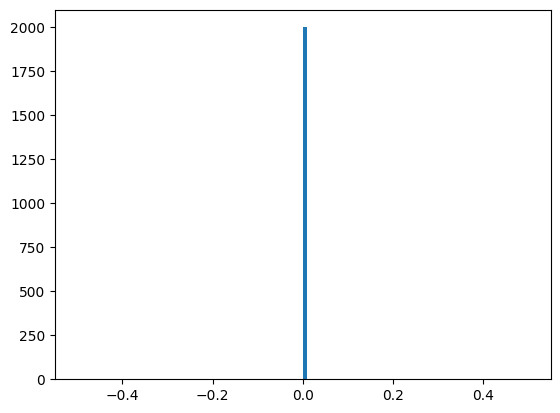

In [44]:
_ = plt.hist(batch['G_s'].cpu().flatten(), bins=100)

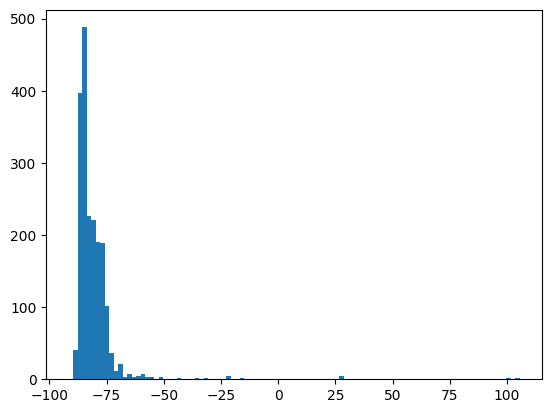

In [45]:
_ = plt.hist(v.cpu().flatten(), bins=100)

In [ ]:
exp_a

tensor([[[1.3557],
         [1.2386],
         [1.0000],
         ...,
         [1.0113],
         [0.9405],
         [0.9926]]], device='cuda:0')

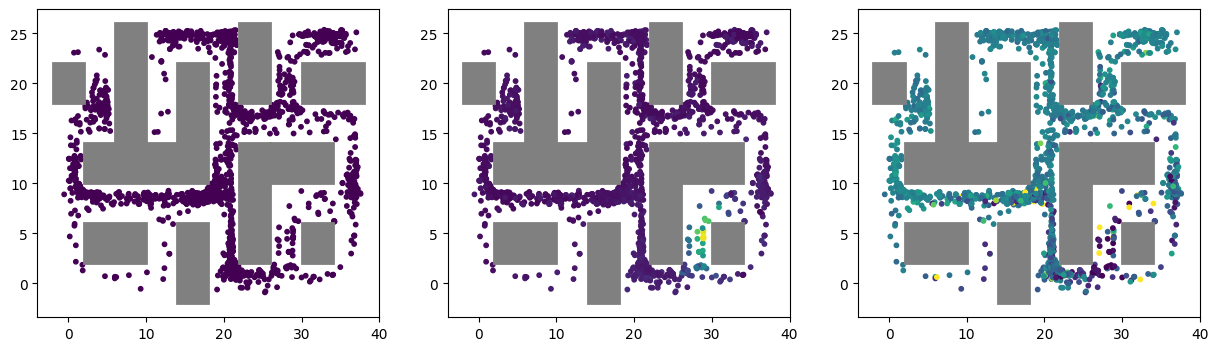

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
_ = axs[0].scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu(), c=batch['G_s'].detach().flatten().cpu(), s=10, alpha=1)
_ = axs[1].scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu(), c=v.detach().flatten().cpu(), s=10, alpha=1)
_ = axs[2].scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu(), c=exp_a.detach().flatten().cpu(), s=10, alpha=1)

add_largest_maze_walls(axs[0])
add_largest_maze_walls(axs[1])
add_largest_maze_walls(axs[2])

In [ ]:
# torch.isclose((0.99 * batch['G_next_s'] + batch['rewards']), batch['G_s'])

In [ ]:
# _ = plt.hist(log_probs.cpu().detach().flatten(), bins=100)

In [ ]:
log_probs[exp_a.squeeze(-1) == 100].mean()

tensor(-1.2929, device='cuda:0', grad_fn=<MeanBackward0>)

In [ ]:
log_probs[exp_a.squeeze(-1) < 1].mean()

tensor(-1.3023, device='cuda:0', grad_fn=<MeanBackward0>)

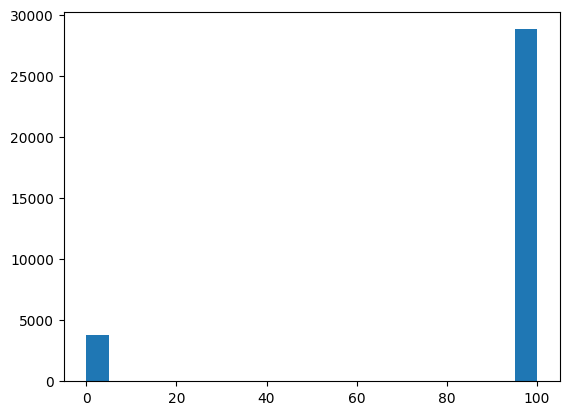

In [ ]:
_ = plt.hist(exp_a.flatten().cpu(), bins=20)

---

---

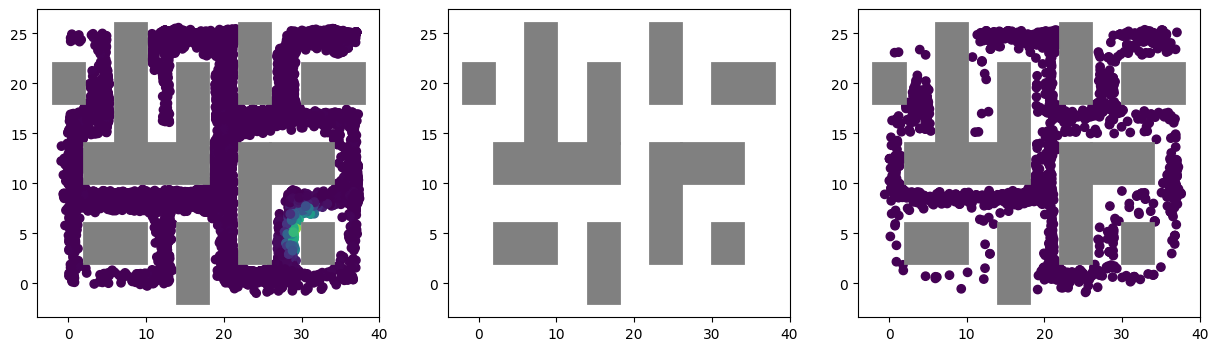

In [49]:
b = 0
eval_states, eval_rewards = get_eval_rewards(w_mean[[b]])

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].scatter(eval_states[..., 0], eval_states[..., 1], c=eval_rewards, vmin=-1, vmax=1)
add_largest_maze_walls(axs[0])


x = batch['states'][b][batch['alpha'][b].bool().squeeze(-1) == 1].cpu()
c = batch['G_s'][b][batch['alpha'][b].bool().squeeze(-1) == 1].cpu()
axs[1].scatter(x[:, 0], x[:, 1], c=c.cpu())
add_largest_maze_walls(axs[1])

x = batch['states'][b][batch['alpha'][b].bool().squeeze(-1) == 0].cpu()
c = batch['G_s'][b][batch['alpha'][b].bool().squeeze(-1) == 0].cpu()
axs[2].scatter(x[:, 0], x[:, 1], c=c.cpu())
add_largest_maze_walls(axs[2])

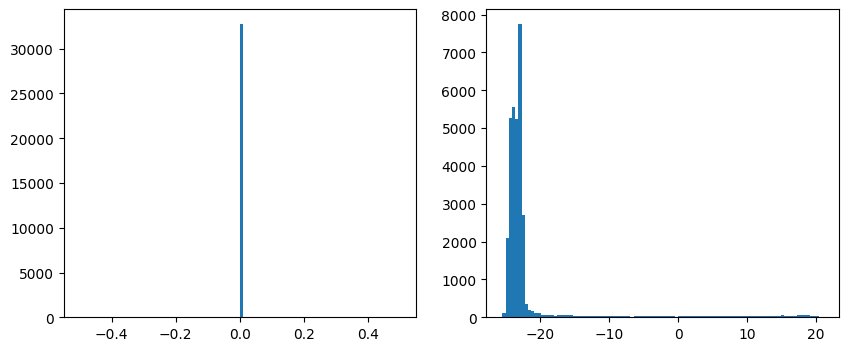

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
cond = batch['G_s'] == 0
_ = axs[0].hist(batch['G_s'][cond].flatten().cpu().detach(), bins=100)
_ = axs[1].hist(v[cond].flatten().cpu().detach(), bins=100)

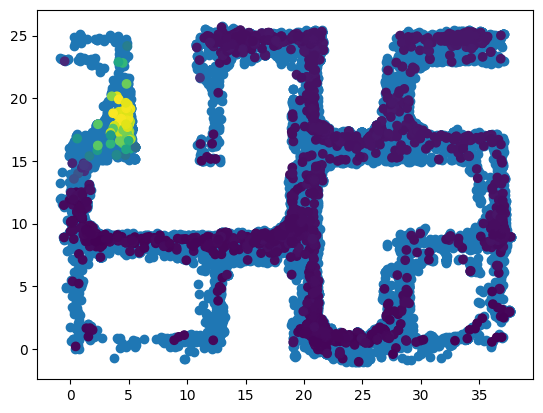

In [ ]:
plt.scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu())
plt.scatter(batch['states'][b, :, 0].cpu(), batch['states'][b, :, 1].cpu(), c=v[b].detach().flatten().cpu())

In [ ]:
data.shape, values.shape

(torch.Size([65536, 2]), torch.Size([65536]))

In [ ]:
data = batch['states'][..., [0, 1]].reshape(-1, 2).cpu()+1 # (N, 2)
values = batch['G_s'].cpu().detach().reshape(-1)  # (N,)
# values = v.cpu().detach().reshape(-1)  # (N,)

# Step 1: Define bin size
bin_size = 0.5

# Step 2: Compute bin indices
bin_coords = (data / bin_size).long()  # (N, 2)

# Step 3: Flatten 2D bin indices to 1D
num_bins_x = int(torch.ceil(data[:, 0].max() / bin_size))
num_bins_y = int(torch.ceil(data[:, 1].max() / bin_size)) + 20
flat_bins = bin_coords[:, 0] + bin_coords[:, 1] * num_bins_y  # (N,)

# Step 4: Aggregate max value per bin
num_total_bins = num_bins_x * num_bins_y
max_per_bin = torch.full((num_total_bins,), float('-inf'))

max_per_bin = max_per_bin.scatter_reduce(0, flat_bins, values, reduce="max", include_self=True)

# Optional: reshape into 2D bin grid
max_grid = max_per_bin.view(num_bins_x, num_bins_y)

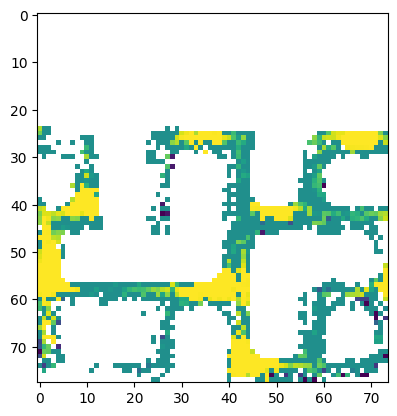

In [ ]:
plt.imshow(max_grid.flip(0))

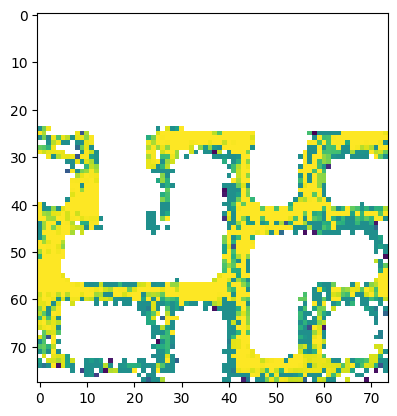

In [ ]:
plt.imshow(max_grid.flip(0))

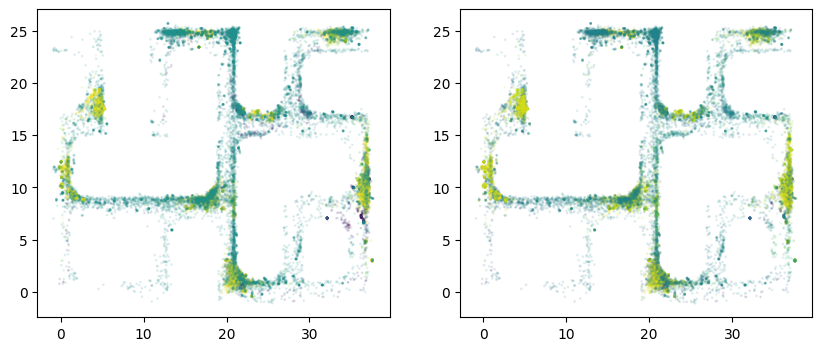

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
_ = axs[0].scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu(), c=batch['G_s'].detach().flatten().cpu(), s=1, alpha=0.1)
_ = axs[1].scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu(), c=v.detach().flatten().cpu(), s=1, alpha=0.1)


# fig, ax = plt.subplots(1, 1)
# # plt.scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu())
# ax.scatter(batch['states'][b, :, 0].cpu(), batch['states'][b, :, 1].cpu(), c=batch['G_s'][b].detach().flatten().cpu(), s=1)
# add_largest_maze_walls(ax)

---

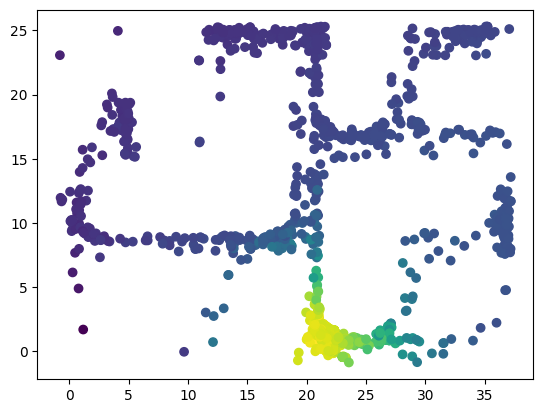

In [ ]:
# reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=128)
# encode_obs = random_states[:, :128, :].to(device)
# encode_rewards = random_states_rewards[:, :128, None].to(device)
# reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)


# batch = get_iql_training_data(
#     batch_size=1, 
#     num_states=10000
# )

# with torch.no_grad():
#     w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)   
#     batch['rewards'] = fre_network.get_reward_pred(w_mean_cst, batch['states'])
    
# plt.scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu(), c=batch['rewards'].cpu())
plt.scatter(batch['states'][b, :, 0].cpu(), batch['states'][b, :, 1].cpu(), c=v[b].detach().flatten().cpu())

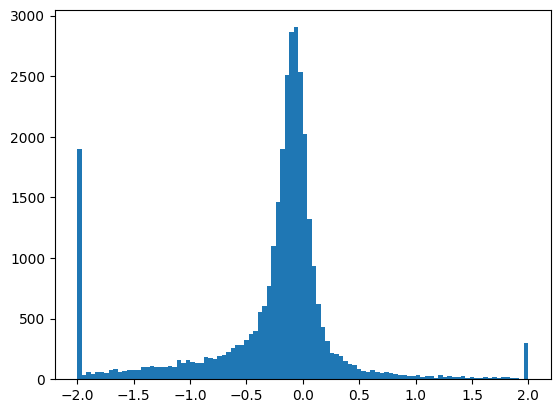

In [ ]:
_ = plt.hist(adv.clip(-2, 2).flatten().cpu(), bins=100)

/tmp/ipykernel_52881/923392994.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('hot')


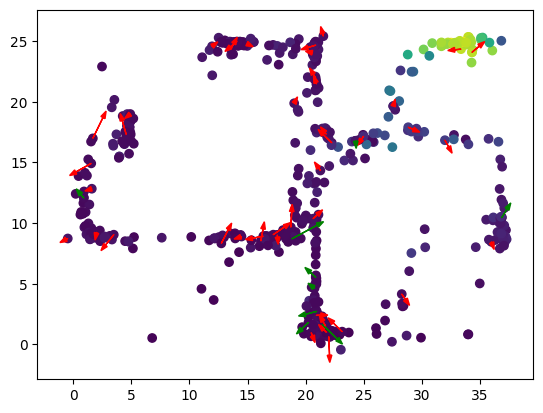

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Example scalar value

# Normalize and map the value to a color
norm = mcolors.Normalize(vmin=-2, vmax=2)
cmap = cm.get_cmap('hot')


plt.scatter(batch['states'][b, :, 0].cpu(), batch['states'][b, :, 1].cpu(), c=v[b].detach().cpu())

states, next_states = batch['states'][b].reshape(-1, 29), batch['next_states'][b].reshape(-1, 29)

for i in range(0, len(states), 10):
    x, y = states[i, [0, 1]].tolist()
    dx, dy = (  (next_states[i, [0, 1]] - states[i, [0, 1]]) * 10 ).tolist()
    plt.arrow(x, y, dx, dy, color='green' if (adv.flatten()[i] > 0) else 'red', head_width=0.4)
    # value = adv.flatten()[i].clip(-2, 2).item()
    # color = cmap(norm(value))
    # plt.arrow(x, y, dx, dy, color=color, head_width=0.4)

# Benchmark:

In [47]:
import matplotlib.patches as patches


def add_largest_maze_walls(ax):    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * 80

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size + 18
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size + 12
        h, w = h * block_size * 2, w * block_size * 2
        w = w * 1.
        y = y * 1.
        rect = patches.Rectangle((x, y), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
        
        
def get_eval_rewards(eval_z, to_keep:list=None): 
    states = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    states = states.to(device)

    res = []
    for i in range(len(eval_z)):
        
        zi = eval_z[i].unsqueeze(0)
        with torch.no_grad():
            x = states.unsqueeze(0)
            if to_keep is not None:
                x = torch.zeros_like(x)
                x[..., to_keep] = states[..., to_keep]
            r = fre_network.get_reward_pred(zi, x).cpu()
            
            res.append(r)
    
    res = torch.stack(res).squeeze(-1)
    
    return x.cpu(), res.cpu()

In [51]:

def run_test(fre_network, iql_agent, benchmark_id, num_evals, num_eval_anchors):


    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]

    produced_trajectories = []
    for _ in range(num_evals):
        

        reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=num_eval_anchors)
        encode_obs = random_states[:, :128, :].to(device)

        # encode_rewards = random_states_rewards[:, :128, None].to(device)
        # decode_rewards = random_states_rewards[:, 128:, None].to(device)

        encode_rewards = benchmark_reward_function(encode_obs.cpu(), benchmark_param).unsqueeze(-1).to(device)

        reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)

        with torch.no_grad():
            w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)  
            
            
            
        env.reset()
        location = (20, 15)
        start_state = reset_to_location(env, location)
        start_state = normalize_dataset_coords(start_state)[..., :]
        state = start_state

        tensor_state = torch.tensor(state).reshape(1, -1).to(device).float() 
    
    
        produced_trajectory = []    

        for step in tqdm(range(2000)):
            
            produced_trajectory.append(state)
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
                dist = iql_agent.get_actor(w_mean, tensor_state)
                action = dist.loc.cpu()
                action = np.array(action[0]).clip(-1, 1)

                
            new_state, _, _, _ = env.step(action)
            
            state = normalize_dataset_coords(new_state)[..., :]
            
        produced_trajectory = np.stack(produced_trajectory)
        produced_trajectories.append(produced_trajectory)
    
    produced_trajectories = np.stack(produced_trajectories)

    return produced_trajectories, w_mean



/home/nazim/.local/lib/python3.10/site-packages/gym/utils/seeding.py:38: DeprecationWarning: WARN: Function `rng.randn(*size)` is marked as deprecated and will be removed in the future. Please use `rng.standard_normal(size)` instead.
  deprecation(


Target Goal:  (32.90271038594727, 25.252467368484755)


100%|██████████| 2000/2000 [00:01<00:00, 1248.70it/s]


Target Goal:  (33.17138353322325, 24.25550249778982)


100%|██████████| 2000/2000 [00:01<00:00, 1298.00it/s]


...

100%|██████████| 2000/2000 [00:01<00:00, 1144.57it/s]


Target Goal:  (32.73512073769024, 25.1437283512179)


100%|██████████| 2000/2000 [00:01<00:00, 1262.34it/s]


Target Goal:  (33.002512751220856, 25.39750254945824)


100%|██████████| 2000/2000 [00:01<00:00, 1300.97it/s]


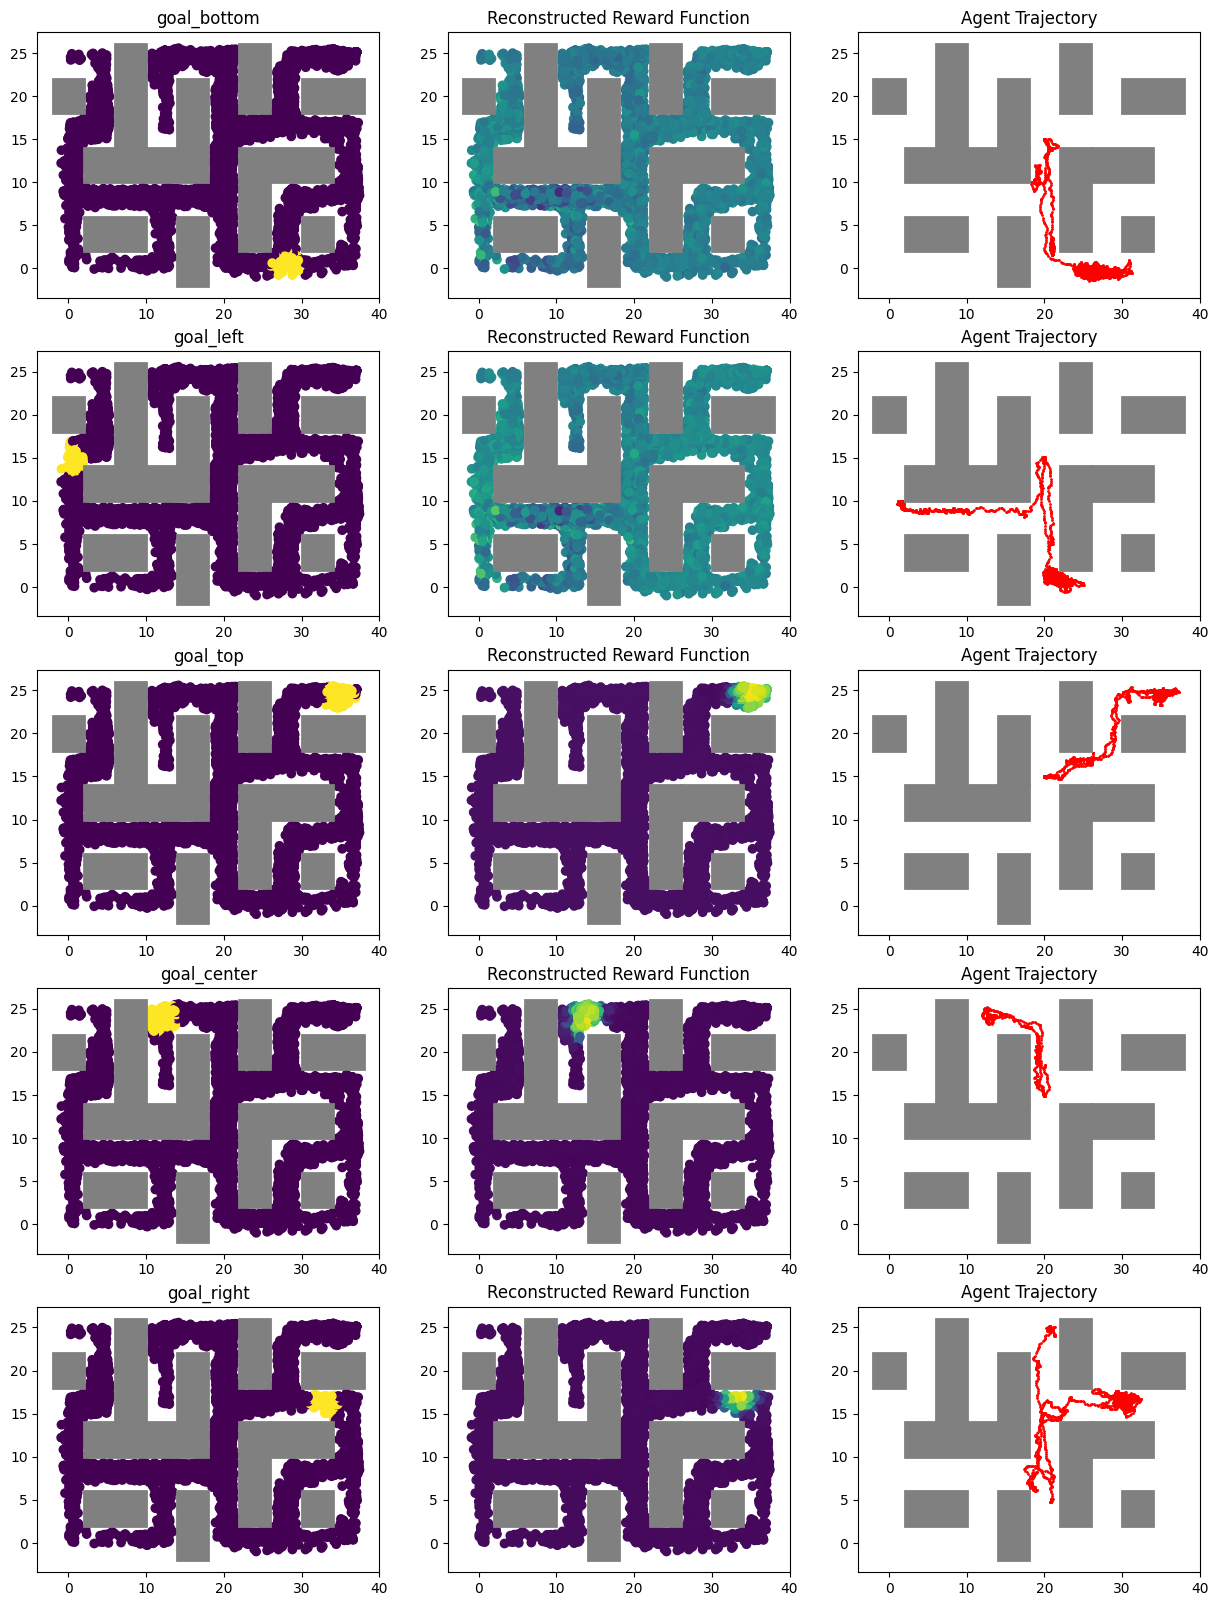

In [52]:
# fig, axs = plt.subplots(len(benchmarks), 3, figsize=(15, len(benchmarks)*4))
fig, axs = plt.subplots(5, 3, figsize=(15, 5*4))

all_produced_trajectories = []
# for benchmark_id in range(len(benchmarks)):
for benchmark_id in range(5):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    
    produced_trajectory, w_mean = run_test(fre_network, iql_agent, benchmark_id=benchmark_id, num_evals=3, num_eval_anchors=128)
    

    eval_states, eval_rewards = get_eval_rewards(w_mean)
    real_eval_rewards = benchmark_reward_function(eval_states, benchmark_param)

    axs[benchmark_id, 0].scatter(eval_states[..., 0], eval_states[..., 1], c=real_eval_rewards)
    axs[benchmark_id, 1].scatter(eval_states[..., 0], eval_states[..., 1], c=eval_rewards)
    axs[benchmark_id, 2].scatter(produced_trajectory[..., 0], produced_trajectory[..., 1], c='red', s=1)
    
    add_largest_maze_walls(axs[benchmark_id, 0])
    add_largest_maze_walls(axs[benchmark_id, 1])
    add_largest_maze_walls(axs[benchmark_id, 2])
    
    # plt.title(f'{benchmark_test_label}')
    axs[benchmark_id, 0].set_title(f'{benchmark_test_label}')
    axs[benchmark_id, 1].set_title(f'Reconstructed Reward Function')
    axs[benchmark_id, 2].set_title(f'Agent Trajectory')
    
    all_produced_trajectories.append(produced_trajectory)
    
all_produced_trajectories = np.stack(all_produced_trajectories)

plt.show()

In [ ]:
trajectory_rewards

tensor([1646., 1132., 1364.])

tensor([0, 0, 0])

In [ ]:
for benchmark_id in range(len(benchmarks)):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    

    trajectory_states = torch.tensor(all_produced_trajectories[benchmark_id]).reshape(1, -1, 29)
    trajectory_states_rewards = benchmark_reward_function(trajectory_states, benchmark_param).float()
    trajectory_states_rewards = trajectory_states_rewards.reshape(
        all_produced_trajectories.shape[1],
        all_produced_trajectories.shape[2],
    )
    trajectory_rewards = trajectory_states_rewards.sum(dim=-1)
    
    if 'goal' in benchmark_test_label: 
        trajectory_rewards = torch.where(trajectory_rewards != -2000, 1., 0.)
        
    print(benchmark_test_label, ':')
    print('\tRewards:', trajectory_rewards.tolist())
    print('\tmean:', trajectory_rewards.mean().item())
    print('\tstd:', trajectory_rewards.std().item())
    
    # break

goal_bottom :
	Rewards: [0.0, 0.0, 0.0, 0.0, 1.0]
	mean: 0.20000000298023224
	std: 0.4472135901451111
goal_left :
	Rewards: [0.0, 0.0, 0.0, 0.0, 0.0]
	mean: 0.0
	std: 0.0
goal_top :
	Rewards: [0.0, 0.0, 0.0, 0.0, 0.0]
	mean: 0.0
	std: 0.0
goal_center :
	Rewards: [0.0, 0.0, 0.0, 0.0, 1.0]
	mean: 0.20000000298023224
	std: 0.4472135901451111
goal_right :
	Rewards: [1.0, 0.0, 0.0, 0.0, 0.0]
	mean: 0.20000000298023224
	std: 0.4472135901451111


IndexError: index 5 is out of bounds for axis 0 with size 5

In [ ]:
all_produced_trajectories[benchmark_id].shape

(2, 10, 29)

4 tensor([-10., -10.]) tensor(-10.) tensor(0.)


In [ ]:
trajectory_rewards

tensor([-10, -10])